In [1]:
import pandas as pd

df = pd.read_csv("GroceryDB_foods.csv")
print(df.columns)

# Drop rows missing store or processing class
df = df.dropna(subset=["store", "f_FPro_class"])

# Keep ultra-processed only
upf = df[df["f_FPro_class"] == 3]

pct = (upf.groupby("store").size() / df.groupby("store").size()) * 100
print(pct)

overall = (len(upf) / len(df)) * 100
print(overall)

Index(['original_ID', 'name', 'store', 'harmonized single category', 'brand',
       'f_FPro', 'f_FPro_P', 'f_min_FPro', 'f_std_FPro', 'f_FPro_class',
       'price', 'price percal', 'package_weight', 'has10_nuts',
       'is_Nuts_Converted_100g', 'Protein', 'Total Fat', 'Carbohydrate',
       'Sugars, total', 'Fiber, total dietary', 'Calcium', 'Iron', 'Sodium',
       'Vitamin C', 'Cholesterol', 'Fatty acids, total saturated',
       'Total Vitamin A'],
      dtype='object')
store
Target        84.407197
Walmart       80.535541
WholeFoods    67.019807
dtype: float64
75.97629140563454


In [ ]:
import pandas as pd

df = pd.read_csv("GroceryDB_foods.csv")

# Drop irrelevant categories
drop_cats = [
    "baby-food",
    "baking",
    "coffee-beans-wf",
    "culinary-ingredients",
    "spices-seasoning",
    "drink-coffee",
    "drink-tea",
    "drink-water-wf",
    "drink-soft-energy-mixes",
    "drink-juice",
    "drink-juice-wf",
    "pudding-jello"
]

df = df[~df["harmonized single category"].isin(drop_cats)]

# Filter out invalid nutrient rows
df = df[df["is_Nuts_Converted_100g"] != -1]

# Energy density
df["energy_kcal_100g"] = (
    4 * df["Protein"] +
    4 * df["Carbohydrate"] +
    9 * df["Total Fat"]
)


df["energy_density"] = df["energy_kcal_100g"] / 100


df = df[df["energy_density"] <= 9]
df = df[df["price percal"] <= df["price percal"].quantile(0.99)]

# Less processed (0–2) and UPF (==3)
less = df[df["f_FPro_class"] <= 2]
upf = df[df["f_FPro_class"] == 3]

# Distributions
price_less = less["price percal"].dropna()
price_upf = upf["price percal"].dropna()

ed_less = less["energy_density"].dropna()
ed_upf = upf["energy_density"].dropna()

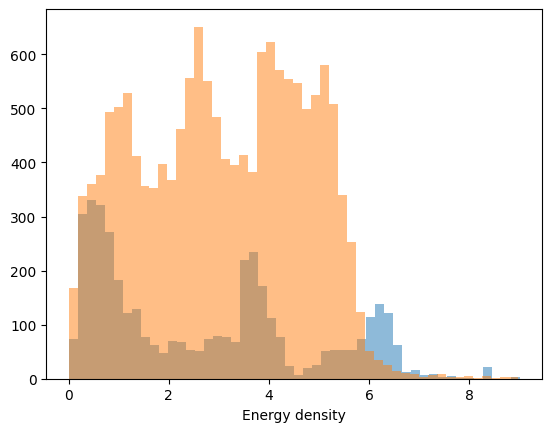

In [29]:
import matplotlib.pyplot as plt

plt.hist(ed_less, bins=50, alpha=0.5, label="Less processed")
plt.hist(ed_upf, bins=50, alpha=0.5, label="Ultra-processed")
plt.xlabel("Energy density")     
plt.show()

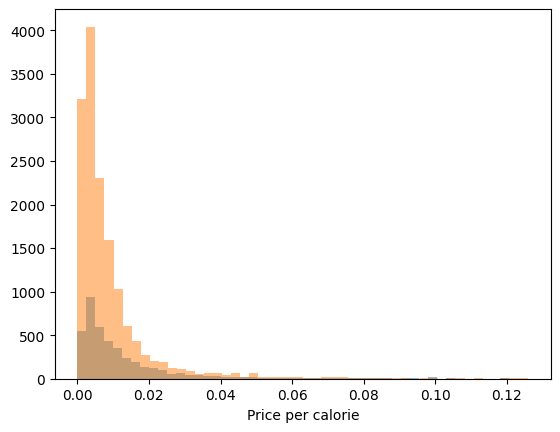

In [30]:
import matplotlib.pyplot as plt

plt.hist(price_less   , bins=50, alpha=0.5, label="Less processed")
plt.hist(price_upf   , bins=50, alpha=0.5, label="Ultra-processed")
plt.xlabel("Price per calorie")     
plt.show()

In [38]:
from scipy.stats import ttest_ind

# Welch t-tests
ppk_t, ppk_p = ttest_ind(price_less, price_upf, equal_var=False)
ed_t,  ed_p  = ttest_ind(ed_less,  ed_upf,  equal_var=False)


print(f"Price per kcal difference: t = {ppk_t:.2f}, p = {ppk_p:.2e}")
print(f"Energy density difference: t = {ed_t:.2f}, p = {ed_p:.2e}")
print("Less processed foods are more expensive per calorie and have lower energy density than ultra-processed foods.")

Price per kcal difference: t = 14.29, p = 1.52e-45
Energy density difference: t = -10.10, p = 8.55e-24
Less processed foods are more expensive per calorie and have lower energy density than ultra-processed foods.


In [37]:
df.to_csv("GroceryDB_foods_filtered.csv", index=False)